In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tabulate import tabulate

### Recording tasks

- Speakers: 162
- Task lists:
    - set A: 30 prompts, used in drunk sessions
    - set NA: 60 prompts, used in sober sessions

The chosen task set depends on the type of session (drunk or sober).
If session number begins with:
- 1 or 3, then set A
- 2 or 4, then set NA 

Important! The task IDs from set A ARE NOT the same as set NA

#### Format of the recording's name:

![Recording Name Format](../RecordingNameFormat.jpg)


5863087001_h_00.wav
- speaker: 586
- session: 3087
- taskID: 001 (from set A)

## Count of tasks types

In [4]:
#Loading Task Prompts
task_folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\DrunkenLinguists\inebriation-voice-detector")
task_file = os.path.join(task_folder, 'TaskACL.xlsx')
drunk_tasks = pd.read_excel(task_file, sheet_name='Drunk tasks')
sober_tasks = pd.read_excel(task_file, sheet_name='Sober tasks')

#Changig column names
drunk_tasks = drunk_tasks.rename(columns={
    'Merge task ID': 'Task ID',
    'Type': 'Type',
    'Subtype': 'Subtype'
})

sober_tasks = sober_tasks.rename(columns={
    'Merge task ID': 'Task ID',
    'Type': 'Type',
    'Subtype': 'Subtype'
})

#Creating mapping dictionaries
drunk_map = dict(zip(drunk_tasks['Drunk Task ID'], drunk_tasks['Task ID']))
sober_map = dict(zip(sober_tasks['Sober task ID'], sober_tasks['Task ID']))

#Function to apply correct mapping acordinng to task set
def map_merge_id(row):
    if row["Task Set"] == 'DRUNK':
        return drunk_map.get(row["Task ID"])
    elif row["Task Set"] == 'SOBER':
        return sober_map.get(row["Task ID"])
    else:
        return None

# Combine task metadata: task ID (Merge Task ID), type, and subtype
task_metadata = pd.concat([drunk_tasks[['Task ID', 'Type', 'Subtype']],
                           sober_tasks[['Task ID', 'Type', 'Subtype']]]).drop_duplicates(subset=["Task ID"])


In [5]:
# Count of type of prompts in the drunk tasks set
drunk_counts = drunk_tasks.groupby(['Type', 'Subtype']).size().reset_index(name='Count')
print("COUNT OF TYPE OF PROMPTS IN THE DRUNK TASKS SET")
print(drunk_counts)

COUNT OF TYPE OF PROMPTS IN THE DRUNK TASKS SET
             Type             Subtype  Count
0   Open question        Give command      5
1   Open question             Narrate      2
2   Open question             Picture      3
3         Reading             Address      5
4         Reading             Command      3
5         Reading  Fast list of words      2
6         Reading       License plate      1
7         Reading              Number      4
8         Reading            Spelling      1
9         Reading         Temperature      1
10        Reading       Tonguetwister      3


In [6]:
# Count of type of prompts in the sober tasks set
sober_counts = sober_tasks.groupby(['Type', 'Subtype']).size().reset_index(name='Count')
print("COUNT OF TYPE OF PROMPTS IN THE SOBER TASKS SET")
print(sober_counts)

COUNT OF TYPE OF PROMPTS IN THE SOBER TASKS SET
             Type             Subtype  Count
0   Open question        Give command     10
1   Open question             Narrate      4
2   Open question             Picture      6
3         Reading             Address     10
4         Reading             Command      8
5         Reading  Fast list of words      2
6         Reading       License plate      2
7         Reading              Number      8
8         Reading            Spelling      1
9         Reading         Temperature      1
10        Reading       Tonguetwister      8


## Analyzing list of recordings

In [7]:
folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC")

#CSV file with the list of recordings
inputTrain_file = 'spectrogram_listTrain.csv'
inputTest_file = 'spectrogram_listTest.csv'
inputVal_file = 'spectrogram_listVal.csv'

#Full path to the CSV file
full_pathTrain = os.path.join(folder, inputTrain_file)
full_pathTest = os.path.join(folder, inputTest_file)
full_pathVal = os.path.join(folder, inputVal_file)

#Reading the CSV file
recording_listTrain = pd.read_csv(full_pathTrain)
recording_listTest = pd.read_csv(full_pathTest)
recording_listVal = pd.read_csv(full_pathVal)

"""File structure:
    0: File name
    1: label
    2: BAC
    3: Task set
    4: Task ID
"""
#Renaming columns
columns = ['File name', 'Label', 'BAC', 'Task Set', 'Task ID']
recording_listTrain.columns = columns
recording_listTest.columns = columns
recording_listVal.columns = columns

#Adding a column to identify the task ID
recording_listTrain['Merge task ID'] = recording_listTrain.apply(map_merge_id, axis=1)
recording_listTest['Merge task ID'] = recording_listTest.apply(map_merge_id, axis=1)
recording_listVal['Merge task ID'] = recording_listVal.apply(map_merge_id, axis=1)

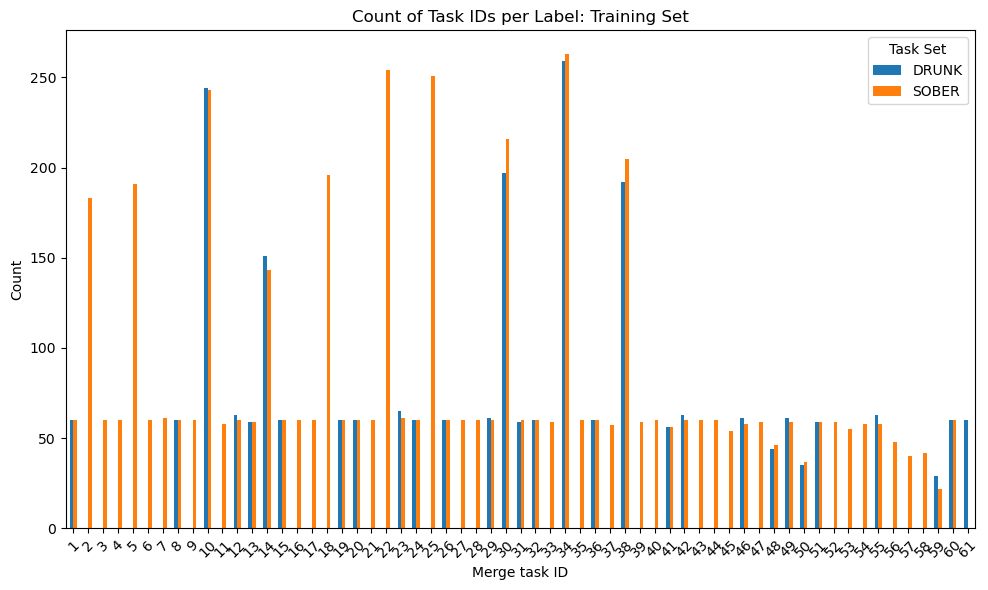

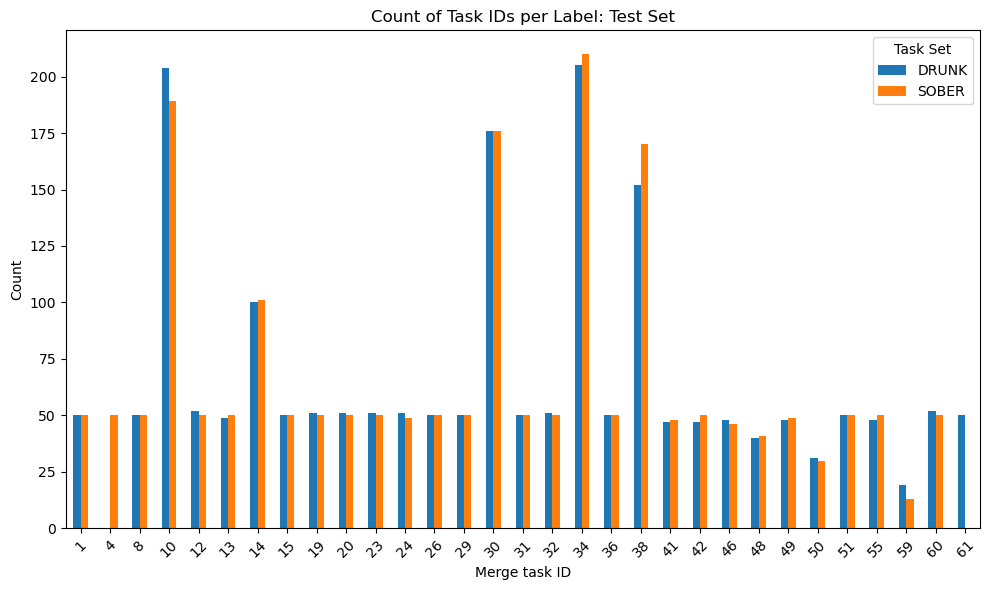

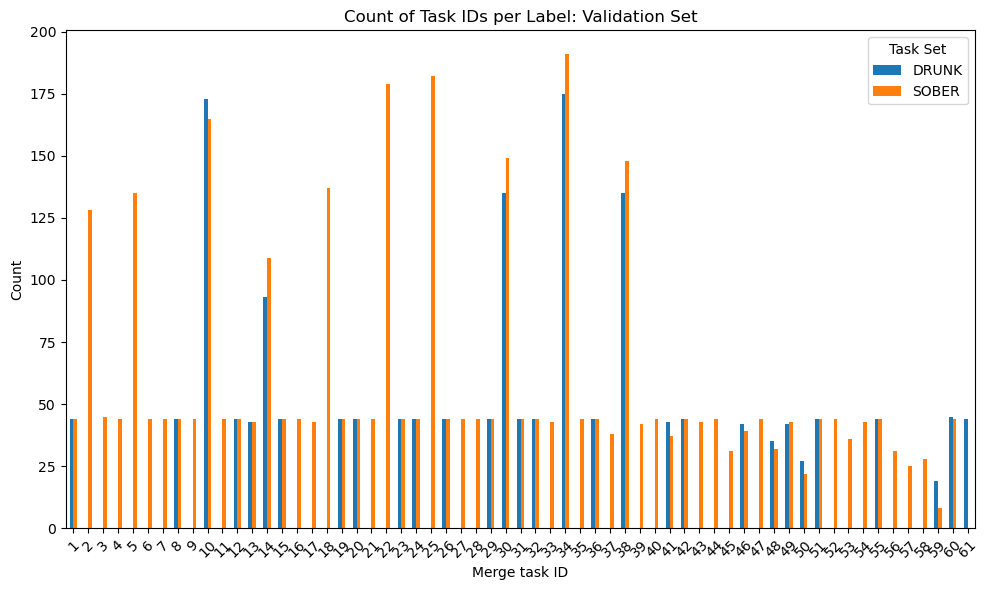

In [8]:
# Count of Drunk and Sober recordings in each recording list
pivot_tableTrain = recording_listTrain.pivot_table(
    index='Merge task ID',
    columns='Task Set',
    aggfunc='size',
    fill_value=0
)

pivot_tableTest = recording_listTest.pivot_table(
    index='Merge task ID',
    columns='Task Set',
    aggfunc='size',
    fill_value=0
)

pivot_tableVal = recording_listVal.pivot_table(
    index='Merge task ID',
    columns='Task Set',
    aggfunc='size',
    fill_value=0
)

#print(pivot_tableTrain)

# Plot the pivot table
pivot_tableTrain.plot(kind='bar', figsize=(10, 6))

plt.title('Count of Task IDs per Label: Training Set')
plt.xlabel('Merge task ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Task Set')
plt.tight_layout()
plt.show()

pivot_tableTest.plot(kind='bar', figsize=(10, 6))

plt.title('Count of Task IDs per Label: Test Set')
plt.xlabel('Merge task ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Task Set')
plt.tight_layout()
plt.show()

pivot_tableVal.plot(kind='bar', figsize=(10, 6))

plt.title('Count of Task IDs per Label: Validation Set')
plt.xlabel('Merge task ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Task Set')
plt.tight_layout()
plt.show()

In [9]:
filtered_df = recording_listTrain[(recording_listTrain['Label'] == 0) & (recording_listTrain['Task Set'].str.upper() == 'DRUNK')]
print(tabulate(filtered_df[['File name','Label','BAC']], headers='keys', tablefmt='grid'))

##Note: there are recordings where the BAC value is low, so the label is 0, but the task set is DRUNK.

+------+-----------------------------------------------------------------------------------------------------+---------+---------+
|      | File name                                                                                           |   Label |     BAC |
+======+=====================================================================================================+=========+=========+
|  100 | c:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC\0241025017_h_00.wav_0_0.jpg |       0 | 0.00023 |
+------+-----------------------------------------------------------------------------------------------------+---------+---------+
|  343 | c:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC\5813082020_h_00.wav_0_0.jpg |       0 | 0.00049 |
+------+-----------------------------------------------------------------------------------------------------+---------+---------+
|  354 | c:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC\50

In [10]:
#Merge with task metadata
merged_dfTrain = recording_listTrain.merge(task_metadata, on='Task ID', how='left')
merged_dfTest = recording_listTest.merge(task_metadata, on='Task ID', how='left')
merged_dfVal = recording_listVal.merge(task_metadata, on='Task ID', how='left')


In [42]:
#Count of type of task acording to label

def barplot_label(df,title,hue,x_axis):
    if hue == 'Task Set':
        label_order=sorted(df[hue].unique(),reverse=True)
    else:
        label_order=sorted(df[hue].unique(),reverse=False)
    plt.figure(figsize=(10,6))
    sns.barplot(data=df, x=x_axis, y='Count', hue=hue,hue_order=label_order)

    plt.title('Count of Task Types per {}: {}'.format(hue,title))
    plt.xlabel('Task Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title=hue)
    plt.tight_layout()
    plt.show()

def count_type_label(df,title):
    print(title.upper())
    print("\nCOUNT OF TYPE OF TASK ACCORDING TO LABEL")
    type_counts = df.groupby(['Label','Type']).size().reset_index(name='Count')
    pivot_type_counts = type_counts.pivot_table(index='Type', columns='Label', values='Count', 
                                            fill_value=0).reset_index()
    print(pivot_type_counts)

    type_counts.sort_values(by='Type', ascending=True, inplace=True)
    barplot_label(type_counts,title,'Label','Type')

    print("\nCOUNT OF TYPE OF TASK ACCORDING TO TASK SET")
    type_counts = df.groupby(['Task Set', 'Type']).size().reset_index(name='Count')
    pivot_type_counts = type_counts.pivot_table(index='Type', columns='Task Set', values='Count', 
                                            fill_value=0).reset_index()
    print(pivot_type_counts)

    barplot_label(type_counts,title,'Task Set','Type')

def barplot_subtype(df,hue):
    if hue == 'Task Set':
        label_order=sorted(df[hue].unique(),reverse=True)
    else:
        label_order=sorted(df[hue].unique(),reverse=False)

    plt.figure(figsize=(10,6))
    sns.barplot(data=df, x='Subtype', y='Count', hue=hue, hue_order=label_order)

    plt.title('Count of Task Subtypes per {}:'.format(hue))
    plt.xlabel('Task Subtype')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title=hue)
    plt.tight_layout()
    plt.show()

def count_type_sublabel(df,title):
    print("\nCOUNT OF SUBTYPE OF TASK ACCORDING TO LABEL")
    subtype_counts = df.groupby(['Label', 'Type', 'Subtype']).size().reset_index(name='Count')

    pivot_counts = subtype_counts.pivot_table(index=['Type', 'Subtype'], 
                                            columns='Label', 
                                            values='Count', 
                                            fill_value=0).reset_index()

    print(pivot_counts)

    subtype_counts.sort_values(by='Subtype', ascending=True, inplace=True)
    barplot_subtype(subtype_counts,'Label')

    print("\nCOUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET")
    subtype_counts = df.groupby(['Task Set', 'Type', 'Subtype']).size().reset_index(name='Count')

    pivot_counts = subtype_counts.pivot_table(index=['Type', 'Subtype'], 
                                            columns='Task Set', 
                                            values='Count', 
                                            fill_value=0).reset_index()

    print(pivot_counts)
    
    subtype_counts.sort_values(by='Subtype', ascending=True, inplace=True)
    barplot_subtype(subtype_counts,'Task Set')



TRAINING SET

COUNT OF TYPE OF TASK ACCORDING TO LABEL
Label           Type       0       1
0      Open question  2808.0  1131.0
1            Reading  2381.0  1150.0


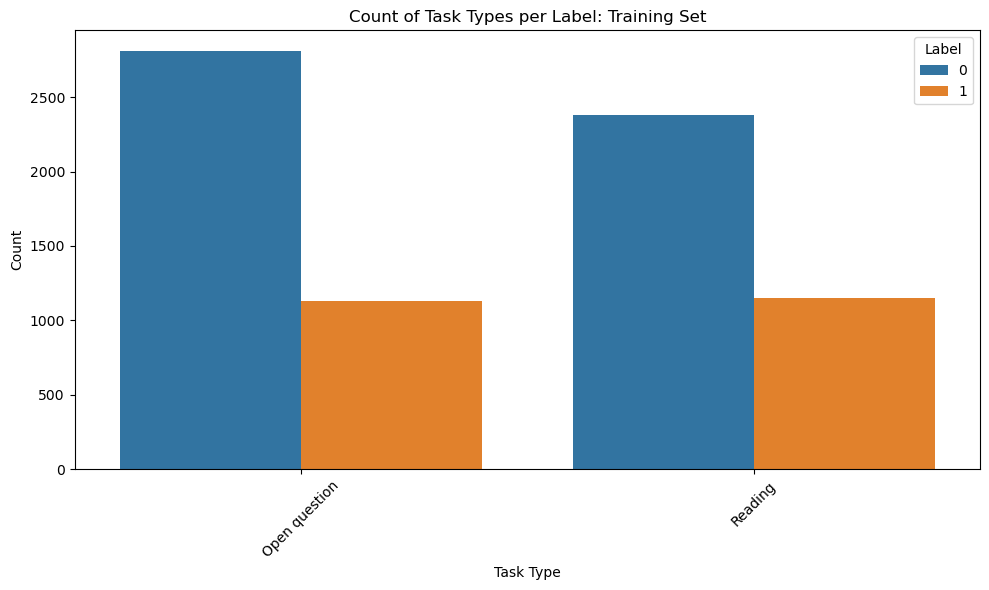


COUNT OF TYPE OF TASK ACCORDING TO TASK SET
Task Set           Type   DRUNK   SOBER
0         Open question  1227.0  2712.0
1               Reading  1254.0  2277.0


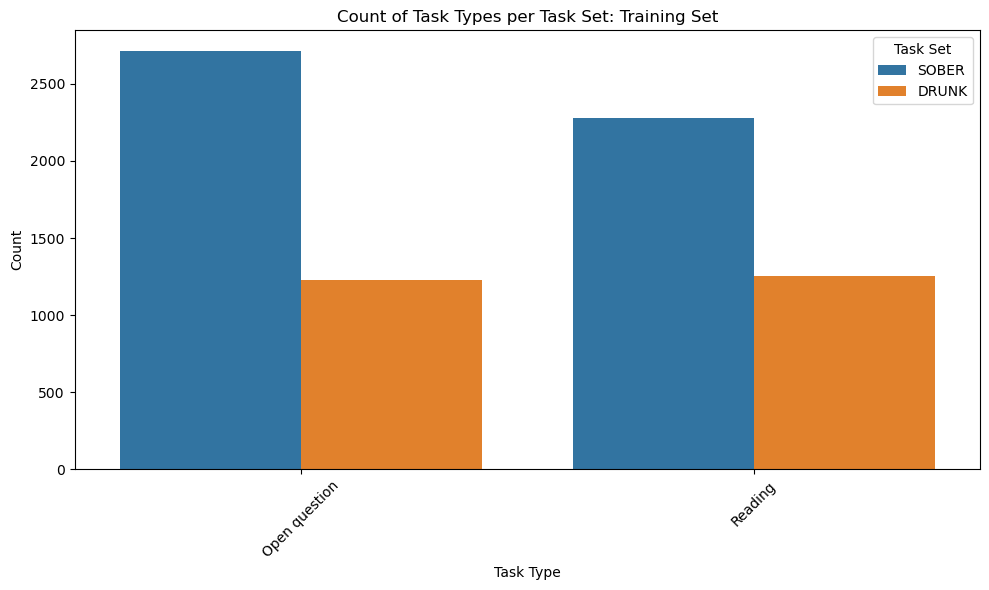


COUNT OF SUBTYPE OF TASK ACCORDING TO LABEL
Label           Type             Subtype       0      1
0      Open question        Give command   567.0    0.0
1      Open question             Narrate   880.0  436.0
2      Open question             Picture  1361.0  695.0
3            Reading             Address   629.0  384.0
4            Reading             Command   367.0    0.0
5            Reading  Fast list of words   125.0   58.0
6            Reading       License plate   123.0   54.0
7            Reading              Number   513.0  362.0
8            Reading            Spelling    60.0    0.0
9            Reading         Temperature    56.0    0.0
10           Reading       Tonguetwister   508.0  292.0


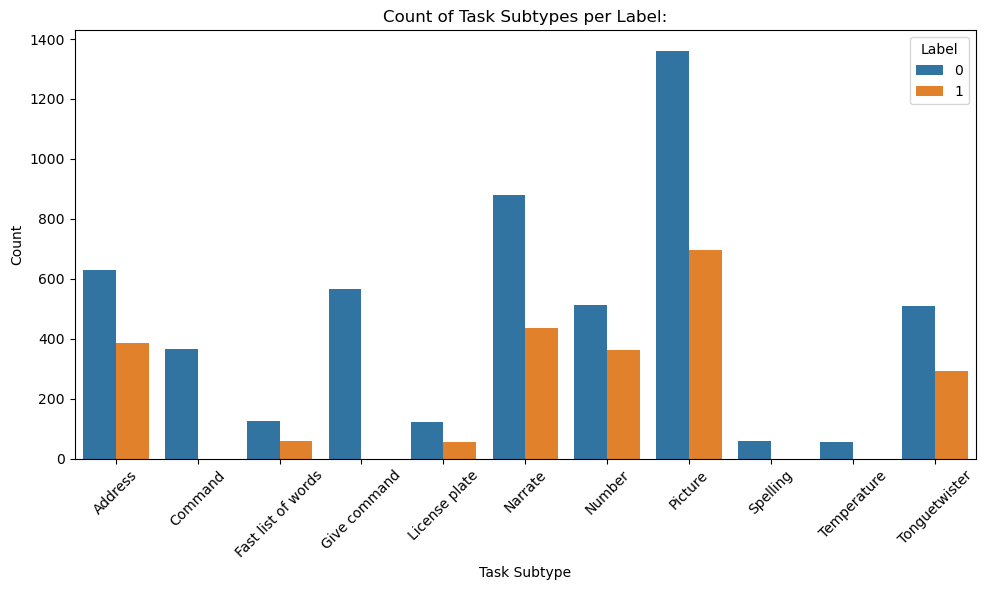


COUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET
Task Set           Type             Subtype  DRUNK   SOBER
0         Open question        Give command    0.0   567.0
1         Open question             Narrate  473.0   843.0
2         Open question             Picture  754.0  1302.0
3               Reading             Address  419.0   594.0
4               Reading             Command    0.0   367.0
5               Reading  Fast list of words   63.0   120.0
6               Reading       License plate   59.0   118.0
7               Reading              Number  395.0   480.0
8               Reading            Spelling    0.0    60.0
9               Reading         Temperature    0.0    56.0
10              Reading       Tonguetwister  318.0   482.0


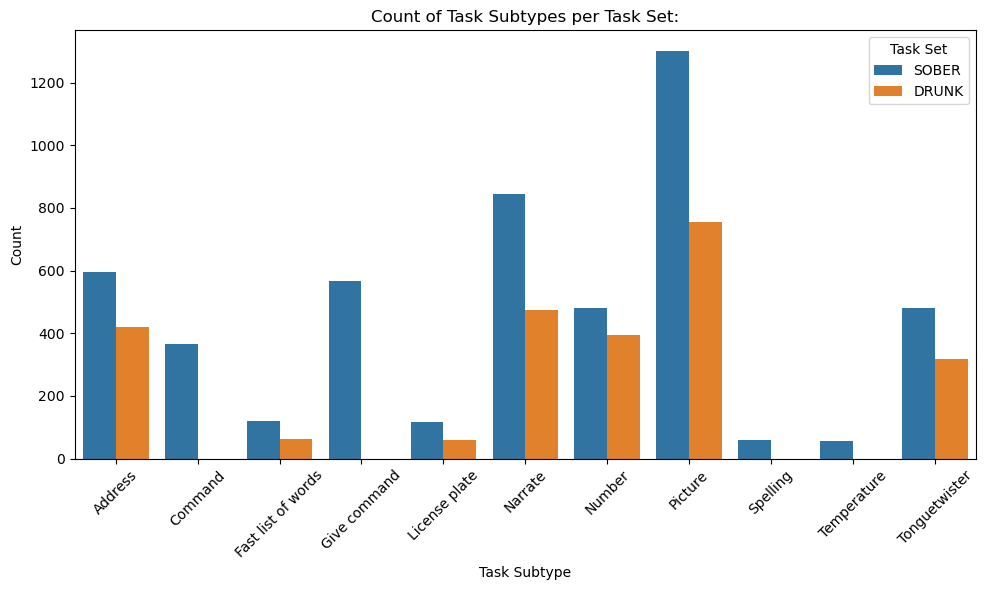

In [43]:
count_type_label(merged_dfTrain,"Training Set")
count_type_sublabel(merged_dfTrain,"Training Set")

TEST SET

COUNT OF TYPE OF TASK ACCORDING TO LABEL
Label           Type       0      1
0      Open question  1163.0  903.0
1            Reading  1024.0  955.0


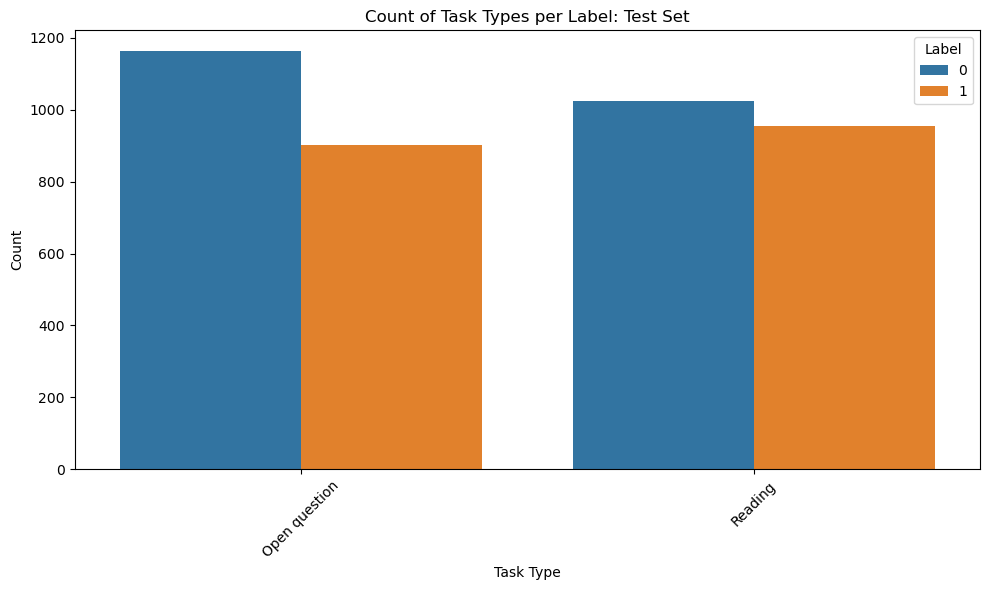


COUNT OF TYPE OF TASK ACCORDING TO TASK SET
Task Set           Type   DRUNK   SOBER
0         Open question   984.0  1082.0
1               Reading  1039.0   940.0


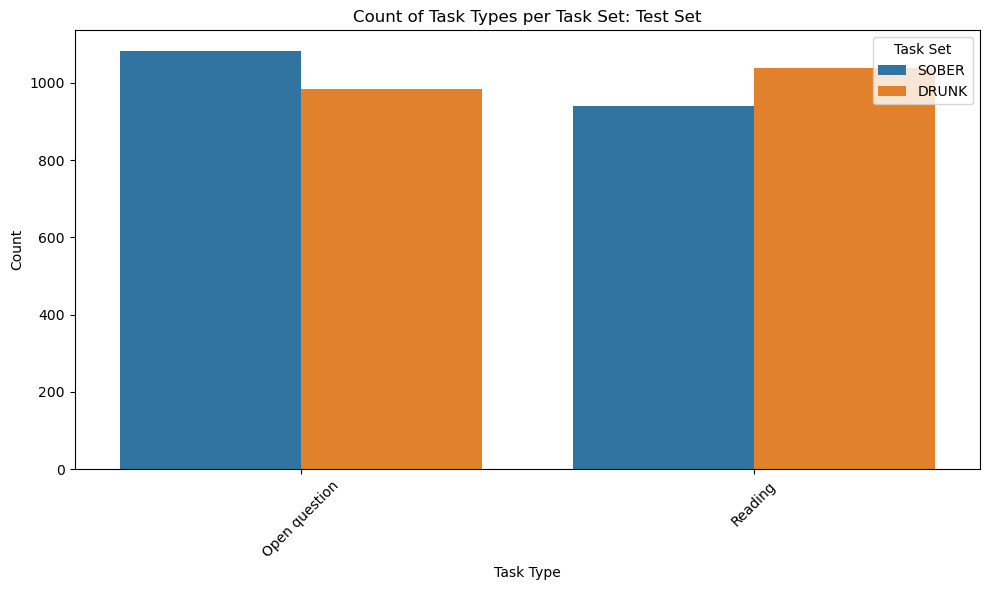


COUNT OF SUBTYPE OF TASK ACCORDING TO LABEL
Label           Type             Subtype      0      1
0      Open question        Give command  236.0    0.0
1      Open question             Narrate  339.0  324.0
2      Open question             Picture  588.0  579.0
3            Reading             Address  277.0  321.0
4            Reading             Command   93.0    0.0
5            Reading  Fast list of words  104.0   48.0
6            Reading       License plate   54.0   46.0
7            Reading              Number  227.0  299.0
8            Reading            Spelling   50.0    0.0
9            Reading         Temperature   48.0    0.0
10           Reading       Tonguetwister  171.0  241.0


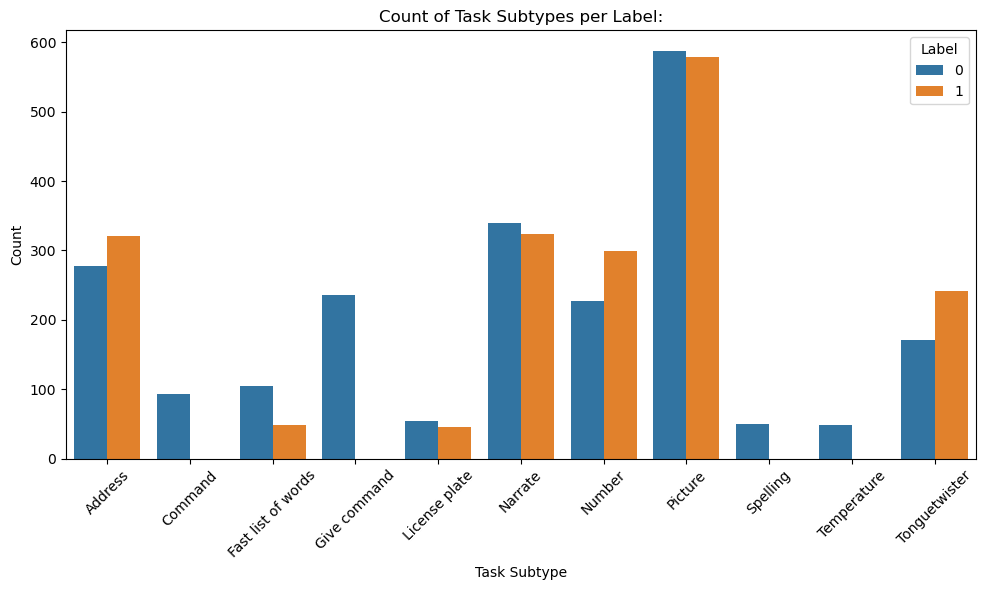


COUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET
Task Set           Type             Subtype  DRUNK  SOBER
0         Open question        Give command    0.0  236.0
1         Open question             Narrate  352.0  311.0
2         Open question             Picture  632.0  535.0
3               Reading             Address  349.0  249.0
4               Reading             Command    0.0   93.0
5               Reading  Fast list of words   52.0  100.0
6               Reading       License plate   50.0   50.0
7               Reading              Number  326.0  200.0
8               Reading            Spelling    0.0   50.0
9               Reading         Temperature    0.0   48.0
10              Reading       Tonguetwister  262.0  150.0


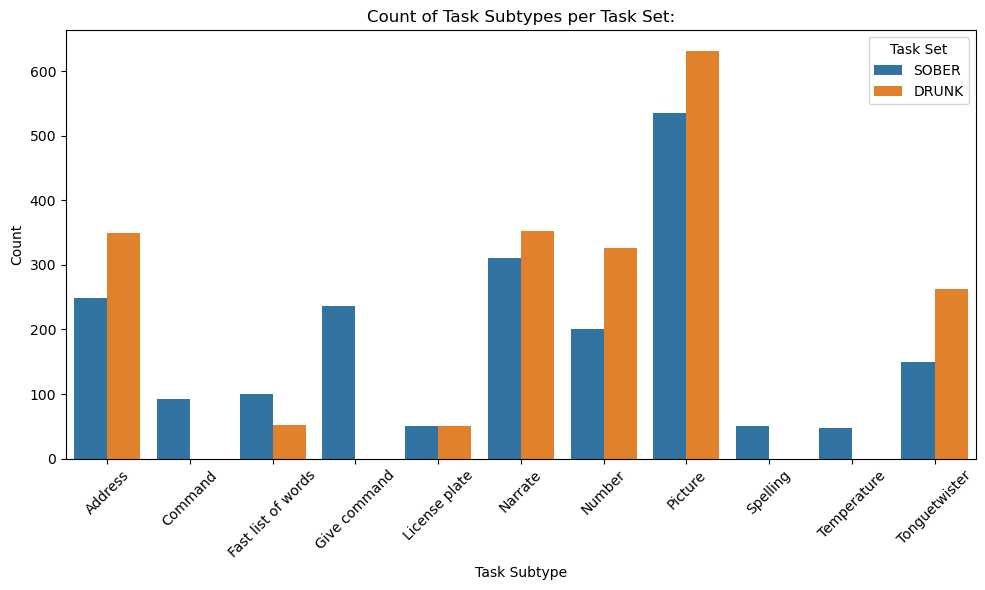

In [44]:
count_type_label(merged_dfTest,"Test Set")
count_type_sublabel(merged_dfTest,"Test Set")

VALIDATION SET

COUNT OF TYPE OF TASK ACCORDING TO LABEL
Label           Type       0      1
0      Open question  2004.0  760.0
1            Reading  1737.0  813.0


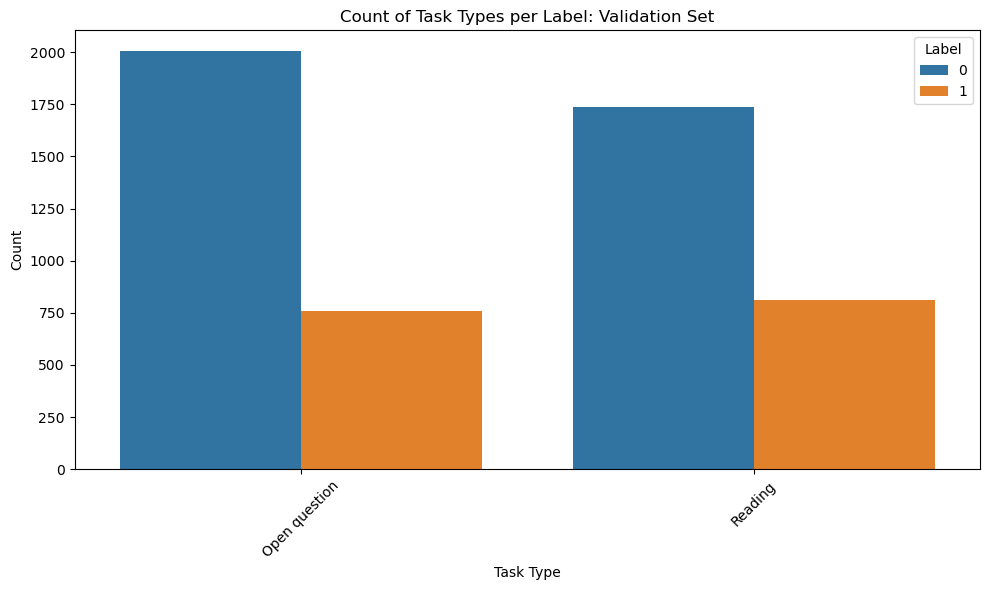


COUNT OF TYPE OF TASK ACCORDING TO TASK SET
Task Set           Type  DRUNK   SOBER
0         Open question  842.0  1922.0
1               Reading  913.0  1637.0


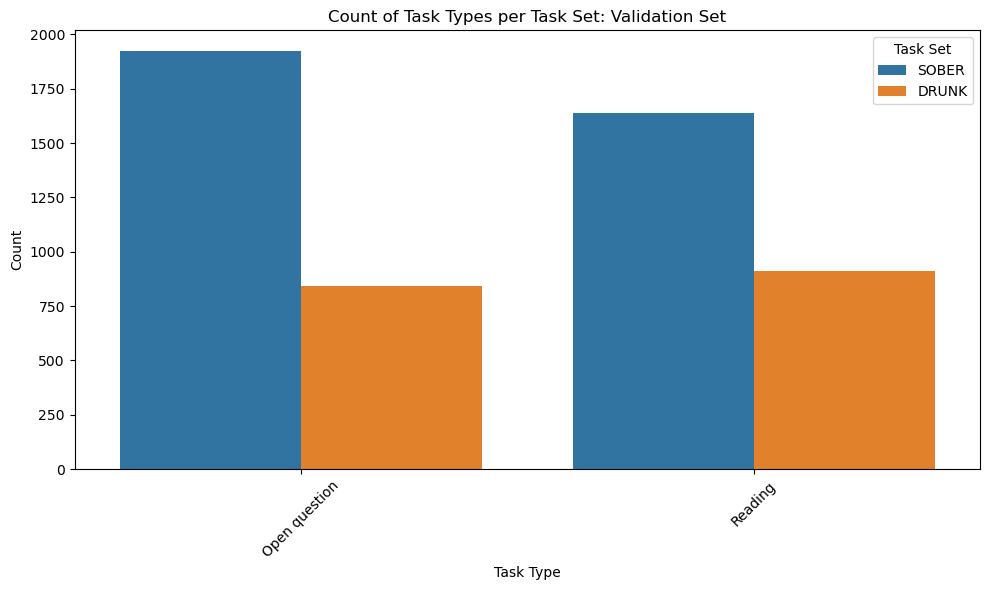


COUNT OF SUBTYPE OF TASK ACCORDING TO LABEL
Label           Type             Subtype      0      1
0      Open question        Give command  399.0    0.0
1      Open question             Narrate  638.0  281.0
2      Open question             Picture  967.0  479.0
3            Reading             Address  463.0  271.0
4            Reading             Command  246.0    0.0
5            Reading  Fast list of words   93.0   39.0
6            Reading       License plate   93.0   39.0
7            Reading              Number  384.0  258.0
8            Reading            Spelling   44.0    0.0
9            Reading         Temperature   37.0    0.0
10           Reading       Tonguetwister  377.0  206.0


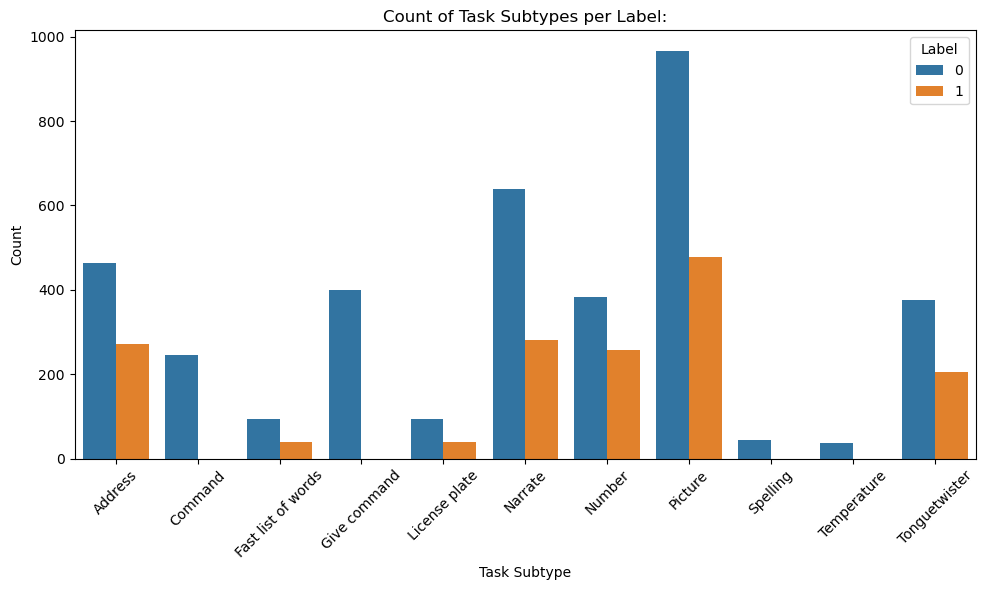


COUNT OF SUBTYPE OF TASK ACCORDING TO TASK SET
Task Set           Type             Subtype  DRUNK  SOBER
0         Open question        Give command    0.0  399.0
1         Open question             Narrate  312.0  607.0
2         Open question             Picture  530.0  916.0
3               Reading             Address  305.0  429.0
4               Reading             Command    0.0  246.0
5               Reading  Fast list of words   44.0   88.0
6               Reading       License plate   44.0   88.0
7               Reading              Number  290.0  352.0
8               Reading            Spelling    0.0   44.0
9               Reading         Temperature    0.0   37.0
10              Reading       Tonguetwister  230.0  353.0


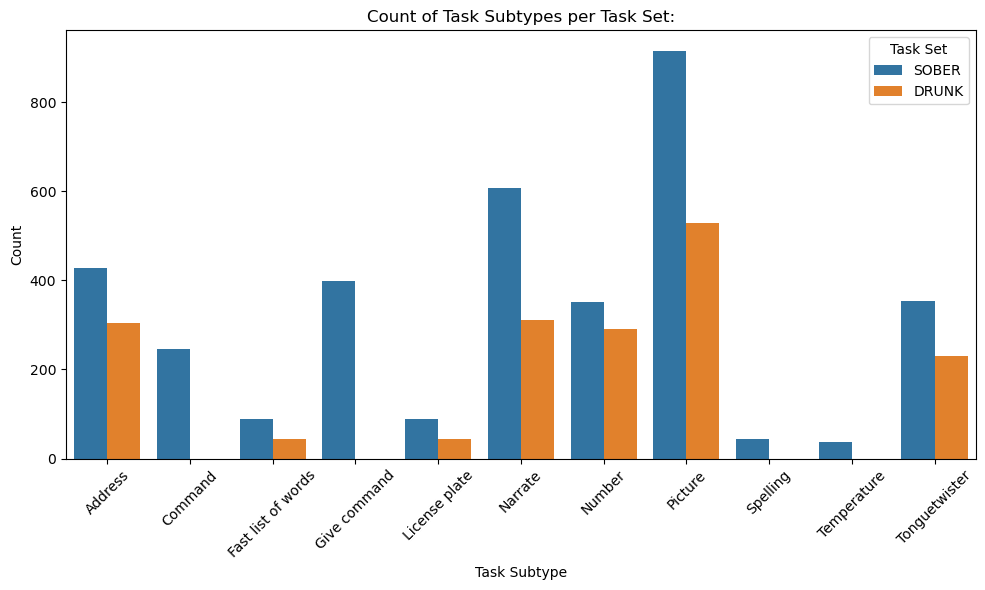

In [45]:
count_type_label(merged_dfVal,"Validation Set")
count_type_sublabel(merged_dfVal,"Validation Set")